In [150]:
#ranyi2 correlator 独立性を見る

Lx=Ly= 12
NT= 2592 sample = 5
Gc (864, 864)
px= 0.2 pz= 0.0 pg= 0.8
ids= 0 it= 2591 TEE= 0
ids= 1 it= 2591 TEE= -1
ids= 2 it= 2591 TEE= 0
ids= 3 it= 2591 TEE= -1
ids= 4 it= 2591 TEE= 0
Np= 11 Nd= 5 NT= 2592 time= 142


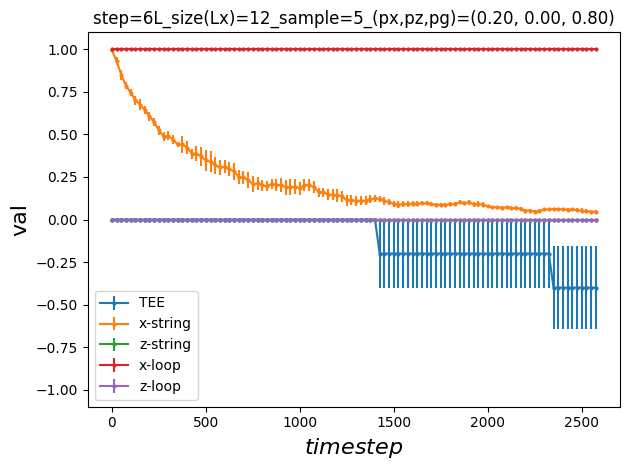

In [18]:
# initial Z px=0 (px,pg)=(1,0) to (px,pg)=(0,1)

from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
from quspin.operators import hamiltonian # Hamiltonians and operators
#from quspin.basis import spinless_fermion_basis_1d # Hilbert space fermion basis
from quspin.basis import spin_basis_1d # Hilbert space spin basis
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
from scipy.linalg import expm, sinm, cosm
from numpy.linalg import multi_dot
from scipy.sparse import csr_matrix, csc_matrix, coo_matrix, lil_matrix
from scipy.sparse.linalg import inv, eigs
from scipy.linalg import svdvals
from scipy.stats import unitary_group
from scipy import linalg
from numpy import linalg as LA
import pylab
import time
import numba
from numba import njit,c16,i8,u2
import sys
import math

np.set_printoptions(precision=2)
np.set_printoptions(suppress=True)
np.set_printoptions(threshold=np.inf, linewidth=np.inf)

time_start = time.time()

def idx(x,y,Lx,Ly):
    return (x % Lx) + Lx * (y % Ly)
def inv_idx(i,Lx,Ly):
    return i % Lx, i // Lx


def dir_x(x,y,Lx,Lv):
    return x+Lx*y
def dir_y(x,y,Lx,Lv):
    return x+Lx*y+Lv
def dir_xy(x,y,Lx,Lv):
    return x+Lx*y+2*Lv


def create_transformation_pv_link(Lv, Lx, Ly):
    #############################################
    ############ plaquette part #################
    #############################################
    p_indd = np.zeros((2*Lx*Ly,3),dtype='uint32')
    for iy in range(Ly):
        for ix in range(Lx):
            #下三角
            ic=(ix%Lx)+Lx*(iy%Ly)
            ipx=(ix+1)%Lx
            ipy=(iy+1)%Ly
            p_indd[ic][0]=dir_x(ix,iy,Lx,Lv)
            p_indd[ic][1]=dir_y(ipx,iy,Lx,Lv)
            p_indd[ic][2]=dir_xy(ix,iy,Lx,Lv)
            #上三角
            p_indd[ic+Lx*Ly][0]=dir_xy(ix,iy,Lx,Lv)
            p_indd[ic+Lx*Ly][1]=dir_x(ix,ipy,Lx,Lv)
            p_indd[ic+Lx*Ly][2]=dir_y(ix,iy,Lx,Lv)

    ############################################
    ############ vertex part ###################
    ############################################
    v_indd = np.zeros((Lx*Ly,6),dtype='uint32')
    for iy in range(Ly):
        for ix in range(Lx):
            ic=(ix%Lx)+Lx*(iy%Ly)
            imx=(ix-1)%Lx
            imy=(iy-1)%Ly
            v_indd[ic][0]=dir_x(ix,iy,Lx,Lv)
            v_indd[ic][1]=dir_xy(ix,iy,Lx,Lv)
            v_indd[ic][2]=dir_y(ix,iy,Lx,Lv)
            v_indd[ic][3]=dir_x(imx,iy,Lx,Lv)
            v_indd[ic][4]=dir_xy(imx,imy,Lx,Lv)
            v_indd[ic][5]=dir_y(ix,imy,Lx,Lv)
    #print(v_indd)
    #print(p_indd)
    return p_indd, v_indd


####################################################
def initial_stabilizer_state(case,Ld,Lxd,Lyd,v_ind,p_ind):
    # Ld: total # of qubits
    MRi=np.zeros((Ld,2*Ld),dtype='uint32')
    if case == 1:
        #Case I: X product state
        for ii in range(Ld):
            MRi[ii][ii]=1 # X
    if case == 2:
        #Case I: Z product state
        for ii in range(Ld):
            MRi[ii][Ld+ii]=1 # Z
    if case ==3:
        ##Case III: unique g.s. of TC 
        ### plaquette stabilizers ZZZ ###
        for ip in range(2*Lxd*Lyd-1):
            MRi[ip][Ld+p_ind[ip][0]]=1 # Z0
            MRi[ip][Ld+p_ind[ip][1]]=1 # Z1
            MRi[ip][Ld+p_ind[ip][2]]=1 # Z2
            #独立ではない最後のBpだけ取らない
        ### vertex stabilizers  XXXXXX ###
        for iv in range((Lxd)*(Lyd)-1):
            ivs=iv+2*Lxd*Lyd-1  # note that iv and ivs are different.
            MRi[ivs][v_ind[iv][0]]=1 # X0
            MRi[ivs][v_ind[iv][1]]=1 # X1
            MRi[ivs][v_ind[iv][2]]=1 # X2
            MRi[ivs][v_ind[iv][3]]=1 # X3
            MRi[ivs][v_ind[iv][4]]=1 # X4
            MRi[ivs][v_ind[iv][5]]=1 # X5
            #独立ではない最後のAvだけ取らない
        ### Add logical operators###
            # x-direction loop logical Z
            for kk in range(Lx):
                iv=(kk%Lx)+Lx*(0%Ly)
                MRi[Ld-2][Ld+v_ind[iv][0]]=1 #Z
            # x-direction loop logical Z
            for kk in range(Ly):
                iv=(0%Lx)+Lx*(kk%Ly)
                MRi[Ld-1][Ld+v_ind[iv][2]]=1 #Z
    #print(MRi)
    return MRi

####################################################
def measurement_op(dMR,Ld,Lxd,Lyd,v_ind,p_ind,Gcd,mtyped):
    Meo=np.zeros(2*Ld,dtype='uint32')
    #
    if mtyped==1: #plaquette or star operator
        todo=[0,1]
        prob_list = [0.5,0.5]
        vorp = np.random.choice(todo,size=None,replace=True, p=prob_list)
        if vorp==0:
            todo=np.arange(Lxd*Lyd)
            vp=np.random.choice(todo,size=None,replace=True,p=None)
            #please check
            Meo[v_ind[vp][0]]=1 #X0
            Meo[v_ind[vp][1]]=1 #X1
            Meo[v_ind[vp][2]]=1 #X2
            Meo[v_ind[vp][3]]=1 #X3
            Meo[v_ind[vp][4]]=1 #X4
            Meo[v_ind[vp][5]]=1 #X5
        else:
            todo=np.arange(2*Lxd*Lyd)
            pp=np.random.choice(todo,size=None,replace=True,p=None)
            #please check
            Meo[Ld+p_ind[pp][0]]=1 #Z0
            Meo[Ld+p_ind[pp][1]]=1 #Z1
            Meo[Ld+p_ind[pp][2]]=1 #Z2
            
    if mtyped==2: #local X
        todo=np.arange(Ld)
        mp=np.random.choice(todo,size=None,replace=True,p=None)
        #please check
        Meo[mp]=1 #X0
        
    if mtyped==3: #local Z
        todo=np.arange(Ld)
        mp=np.random.choice(todo,size=None,replace=True,p=None)
        #please check
        Meo[Ld+mp]=1 #X0
    
    # Meo without outcome sign
    MeoF=np.zeros(2*Ld,dtype='uint32')
    MeoF=Meo

    #print("このオペレーターが")
    #print(MeoF)    
    # dMR without foctor
    dMRF=np.zeros((Ld,2*Ld),dtype='uint32')
    dMRF=dMR

    #print("この状態に作用")   
    #print(dMR)    
    
    #check anti commtation
    Mgs=np.dot(dMRF,np.dot(Gcd,MeoF.T))      
    Mgs=Mgs%2  ## check: reduce Z2 value 

    #print("反交換するスタビライザーは１を返すのでその場所を探す")     
    #print(Mgs)  
    
    antic_index_list=[]
    aid=np.where(Mgs[:]!=0)
    antic_index_list=aid[0]

    #print(aid[0],"番目のスタビライザーと反交換する")
    
    #######
    lenMe=len(antic_index_list)
    if lenMe !=0:
        kc=antic_index_list[0]
        dMR_prev=dMR[kc].copy()
        #replace stabilizer for kc
        
        dMR[kc]=Meo
        #print(kc,"番目のスタビライザーとオペレーターを交換")
        #print(dMR) 
        
        update_list=np.delete(antic_index_list,0)
        
        dMR[update_list,:]=np.mod(dMR[update_list,:]+dMR_prev,2)
        #print("反交換するスタビライザーの残りは最初の反交換するスタビライザーをかけて交換するように変形する")
        #print(update_list,"番目のスタビライザーを更新")
        #print(dMR) 
    return dMR

def subset2(Ld,Ax,Ay,Lx,Ly,p_indd):
    i = idx(Ax,Ay,Lx,Ly)
    Asub_set = set()
    for j in range(3):
        Asub_set.add(p_indd[i][j]) #三角形
        Asub_set.add(p_indd[i + Lx*Ly][j]) #逆三角形
        print(p_indd[i][j])
        print(p_indd[i + Lx*Ly][j])
    return Asub_set

def subset6(Ld,Ax,Ay,Lx,Ly,p_indd):
    Asub_set = set()
    Amx=(Ax - 1) % Lx
    Amy=(Ay - 1) % Ly
    i0 = idx(Ax,Ay,Lx,Ly)
    i1 = idx(Amx,Amy,Lx,Ly)
    i2 = idx(Amx,Ay,Lx,Ly)
    i3 = idx(Ax,Amy,Lx,Ly)
    for j in range(3):
        Asub_set.add(p_indd[i0][j])
        Asub_set.add(p_indd[i0 + Lx*Ly][j])
        Asub_set.add(p_indd[i1][j])
        Asub_set.add(p_indd[i1 + Lx*Ly][j])
        Asub_set.add(p_indd[i2][j])
        Asub_set.add(p_indd[i3+Lx*Ly][j])
    return Asub_set

# https://arxiv.org/abs/2204.08489
def EE_cal(MRd,Asub_set,Ld):
    # partition #
    #LA=Ld//2
    Asub=list(Asub_set)
    LA=len(Asub)
    MRdA=np.zeros((Ld,2*(len(Asub))),dtype='uint32')
    #print("new",Asub)
    for k2 in range(len(Asub)):
        MRdA[:,k2]=MRd[:,Asub[k2]].copy()
        MRdA[:,(LA)+k2]=MRd[:,(Ld)+Asub[k2]].copy()
    #print(MRdA.shape)
    #print(MRdA)
    rankA=rank_mod2_v3(MRdA)
    #print(rankA)
    EEd=rankA-(LA)
    return EEd

#############################
def rank_mod2_v3(MRdd):
    # MRdA construct
    i = 0
    Ic = MRdd.shape[0]
    Jc = MRdd.shape[1]
    for j in range(Jc):
        check_ind=np.where(MRdd[i:,j]==1)
        if len(check_ind[0]) !=0:
            if len(check_ind[0]) >1:
                elim_ind=np.delete(check_ind,0)
                MRdd[elim_ind+i,:]=np.mod(MRdd[elim_ind+i,:]+MRdd[check_ind[0][0]+i,:],2)
            MRdd[i,:],MRdd[check_ind[0][0]+i,:] = MRdd[check_ind[0][0]+i,:],MRdd[i,:].copy()
            i=i+1
    return i

#####    Renyi2-correlator-csr  ######
def Renyi2_create(Ld,Lv,Lxd,Lyd):
    STx = np.zeros((2*Ld,(Lxd-1)*Lyd),dtype='uint32')
    STz = np.zeros((2*Ld,(Lxd-1)*Lyd),dtype='uint32')
    i=0
    for piy in range(Lyd):

        #zig-zag
        for leng in range(Lxd-1):
            leng = leng +1
            for ld in range(leng):
                ipd=ld+piy*Lxd
                ix,iy = inv_idx(ipd,Lxd,Lyd)
                di1=dir_y(ix,iy,Lxd,Lv)    
                di2=dir_xy(ix,iy,Lxd,Lv)
                #print(piy,leng,diz1+Ld,diz2+Ld)
                STx[di1,i]=1
                STx[di2,i]=1    
                STz[di1+Ld,i]=1
                STz[di2+Ld,i]=1            
            i+=1
    STx_list= csr_matrix(STx)
    STz_list= csr_matrix(STz)
    return STx_list, STz_list

def Renyi2_loop_create(Ld,Lv,Lxd,Lyd):
    STx = np.zeros((2*Ld,Lyd),dtype='uint32')
    STz = np.zeros((2*Ld,Lyd),dtype='uint32')
    i=0
    for piy in range(Lyd):
        #zig-zag
        for ld in range(Lxd):
            ipd=ld+piy*Lxd
            ix,iy = inv_idx(ipd,Lxd,Lyd)
            di1=dir_y(ix,iy,Lxd,Lv)    
            di2=dir_xy(ix,iy,Lxd,Lv)
            #print(piy,leng,diz1+Ld,diz2+Ld)
            STx[di1,i]=1
            STx[di2,i]=1    
            STz[di1+Ld,i]=1
            STz[di2+Ld,i]=1            
        i+=1
    STx_list= csr_matrix(STx)
    STz_list= csr_matrix(STz)
    return STx_list, STz_list

def Gc(L):
    Gc=np.zeros((2*L,2*L),dtype='uint32') # 2L * 2L matrix
    for k in range(L):
        Gc[k][L+k]=1
        Gc[L+k][k]=1  
    Gc_csr=csr_matrix(Gc)
    return Gc_csr

def Renyi2_csr(dMR,Gcd_csr,ST_csr,Lxd,Lyd):
    dMR_csr = csr_matrix(dMR)
    Mgs=(dMR_csr.dot(Gcd_csr.dot(ST_csr))).toarray()

    """ST_dense = ST_csr.toarray()
    GST_dense = (Gcd_csr.dot(ST_csr)).toarray()
    dMR_dense = dMR_csr.toarray()
    print("ST")
    print(ST_dense.shape)
    print(ST_dense)
    print("G_ST")
    print(GST_dense.shape)
    print(GST_dense)
    print("MR")
    print(dMR_dense.shape)
    print(dMR_dense)"""
    #print("Mgs")
    #print(Mgs)
    
    R2_element=np.all((Mgs%2)<0.1,axis=0)
    #print(R2_element)
    R2sum=np.sum(R2_element.astype(int))#       
    return R2sum/((Lxd-1)*Lyd)
################################

    
def dephasing_dlinkXZ(dMR,ipd,dired,nsdd2,Ld,Lxd,Lyd,LOcheckd):
    #target dephasing links (please check 9/9)
    ix,iy = ipd%Lxd,ipd//Lxd
    if dired==0:
        if iy==0:
            diz=ix+(Ld-Lxd)
            dix=((ix+1)%Lxd)
        else:
            diz=ix+(Lxd)+(2*Lxd)*(iy-1)
            dix=(ix+1)%Lxd+(Lxd)+(2*Lxd)*(iy-1)+Lxd
    else:
        diz = ix+(Lxd)+(2*Lxd)*(iy-1)+Lxd
        dix = ix+(Lxd)+(2*Lxd)*(iy-1)+(2*Lxd)
    #print(888,ipd,dired,diz,dix)
    
    #di=di.astype('int64')
    MRXZ_bzbx=np.zeros((Ld),dtype='uint32')
    for kk in range(nsdd2):
        MRXZ_bzbx[kk]=dMR[kk,diz]+dMR[kk,dix+Ld] #(9/23,checked)
    MRXZ_bzbx=np.mod(MRXZ_bzbx,2)
    #################
    aid=np.where(MRXZ_bzbx[:]==1) # anticommute X search (9/9,please check)
    di_index_list=aid[0]
    lendi=len(di_index_list)
    # logical X string anticommute check
    if lendi !=0:
        if (di_index_list[0]==nsdd2-1) or (di_index_list[0]==nsdd2-2):
            #print(ipd,diz,dix)
            LOcheckd=1
            #print("logical X lost")

    if lendi !=0:
        k0=di_index_list[0]
        dMR_prev=dMR[k0,:].copy()
        #replace stabilizer for kc
        update_list=np.delete(di_index_list,0)
        dMR[update_list,:]=np.mod(dMR[update_list,:]+dMR_prev,2)
        dMR = np.delete(dMR,k0,0)
        nsdd2-=1
    #print("dephasingZZ2-a",(dMR2[:,di]+dMR2[:,(di+1)%Ld]))
    #print("------------------")
    return dMR,nsdd2,LOcheckd




Np=11
Nd = 5 #800 sample number

#case1= X,case2= Z, case3= ground state of TC
case=1


data_set = {}

Lx,Ly=12,12

print("Lx=Ly=",Lx)
Lv=Lx*Ly # total # of vertex
L=3*Lv # total # of link qubits
Lp=2*Lv  # total # of plaquette
#NT=6*L #*L #4*L total time step

alpha=6

NT=alpha*L #*L #4*L total time step

print("NT=",NT,"sample =",Nd)

p_indd, v_indd=create_transformation_pv_link(Lv, Lx, Ly)

Gc_csr=Gc(L)
Gc = Gc_csr.toarray()
print("Gc",Gc.shape)

p_list=[]
t_list=[]
TEE_ave=[]
TEE_error=[]
TEE_var=[]

R2x_ave=[]
R2x_error=[]
R2x_var=[]

R2z_ave=[]
R2z_error=[]
R2z_var=[]

R2x_loop_ave=[]
R2x_loop_error=[]
R2x_loop_var=[]

R2z_loop_ave=[]
R2z_loop_error=[]
R2z_loop_var=[]



# initial case =1
px=0.2
pg=0.8
pz=1-px-pg

print("px=",px,"pz=",pz,"pg=",pg)

p_list=np.append(p_list,pg)
# stabilizer matrix
MR=np.zeros((L,2*L),dtype='uint32') # L * 2L matrix
# sample set of physical quantity
MR0=initial_stabilizer_state(case,L,Lx,Ly,v_indd,p_indd)

TEE_list = np.zeros((Nd, NT))
R2x_list = np.zeros((Nd, NT))
R2z_list = np.zeros((Nd, NT))
R2x_loop_list = np.zeros((Nd, NT))
R2z_loop_list = np.zeros((Nd, NT))
for ids in range(Nd):
    MR=MR0.copy()

    rank_MR=rank_mod2_v3(MR)
    #print("MR=",MR)
    #print("rank=",rank_MR)
    #sys.exit()
    #MR=MR0.copy()だとTEE=-0.91(NT=4L)、TEE=-1.0(NT=6L)
    #MR=MR0だとTEE=-1(NT=4L)
    #measurement dynamics

    prob_list=[pg,px,pz]
    todo=[1,2,3]


    Ax,Ay=Lx//2,Ly//2
    Bx,By=Ax-2,Ay-1
    Cx,Cy=Ax-1,Ay-2     

    A = subset6(L,Ax,Ay,Lx,Ly,p_indd)
    B = subset6(L,Bx,By,Lx,Ly,p_indd) - A
    C = subset6(L,Cx,Cy,Lx,Ly,p_indd) - A -B
    AB= A|B
    BC= B|C
    CA= C|A
    ABC=AB|C
    
    for it in range(NT):
        t_list=np.append(t_list,it)
        mtype= np.random.choice(todo,size=None,replace=True,p=prob_list)
        MR=measurement_op(MR,L,Lx,Ly,v_indd,p_indd,Gc,mtype)

        SA=EE_cal(MR,A,L)
        SB=EE_cal(MR,B,L)
        SC=EE_cal(MR,C,L)
        SAB=EE_cal(MR,AB,L)
        SBC=EE_cal(MR,BC,L)
        SCA=EE_cal(MR,CA,L)
        SABC=EE_cal(MR,ABC,L)

        TEE=SA+SB+SC-SAB-SBC-SCA+SABC

        STx_csr,STz_csr=Renyi2_create(L,Lv,Lx,Ly)
        STx_loop_csr,STz_loop_csr=Renyi2_loop_create(L,Lv,Lx,Ly)
        #ST_dense = ST_list.toarray()
        #print(ST_dense.shape)
        #print(ST_dense)
        R2x=Renyi2_csr(MR,Gc_csr,STx_csr,Lx,Ly)
        R2z=Renyi2_csr(MR,Gc_csr,STz_csr,Lx,Ly)
        R2x_loop=Renyi2_csr(MR,Gc_csr,STx_loop_csr,Lx,Ly)
        R2z_loop=Renyi2_csr(MR,Gc_csr,STz_loop_csr,Lx,Ly)

        R2x_loop = R2x_loop*(Lx-1)
        R2z_loop = R2z_loop*(Lx-1)
        #print("ids=",ids,"it=",it,"TEE=",TEE)
        TEE_list[ids, it] = TEE
        R2x_list[ids, it] = R2x
        R2z_list[ids, it] = R2z
        R2x_loop_list[ids, it] = R2x_loop
        R2z_loop_list[ids, it] = R2z_loop
        if it == NT-1:
            print("ids=",ids,"it=",it,"TEE=",TEE)


TEE_ave = np.mean(TEE_list, axis=0)
TEE_error = np.std(TEE_list, axis=0, ddof=1) / np.sqrt(Nd)

R2x_ave = np.mean(R2x_list, axis=0)
R2x_error = np.std(R2x_list, axis=0, ddof=1) / np.sqrt(Nd)

R2z_ave = np.mean(R2z_list, axis=0)
R2z_error = np.std(R2z_list, axis=0, ddof=1) / np.sqrt(Nd)

R2x_loop_ave = np.mean(R2x_loop_list, axis=0)
R2x_loop_error = np.std(R2x_loop_list, axis=0, ddof=1) / np.sqrt(Nd)

R2z_loop_ave = np.mean(R2z_loop_list, axis=0)
R2z_loop_error = np.std(R2z_loop_list, axis=0, ddof=1) / np.sqrt(Nd)

    
    
"""if len(TEE_list) > 1:
TEE_aved = np.mean(TEE_list)
TEE_vard = np.var(TEE_list)
TEE_errord = np.std(TEE_list, ddof=1) / np.sqrt(len(TEE_list))

R2x_aved = np.mean(R2x_list)
R2x_vard = np.var(R2x_list)
R2x_errord = np.std(R2x_list, ddof=1) / np.sqrt(len(R2x_list))

R2z_aved = np.mean(R2z_list)
R2z_vard = np.var(R2z_list)
R2z_errord = np.std(R2z_list, ddof=1) / np.sqrt(len(R2z_list))

R2x_loop_aved = np.mean(R2x_loop_list)
R2x_loop_vard = np.var(R2x_loop_list)
R2x_loop_errord = np.std(R2x_loop_list, ddof=1) / np.sqrt(len(R2x_loop_list))

R2z_loop_aved = np.mean(R2z_loop_list)
R2z_loop_vard = np.var(R2z_loop_list)
R2z_loop_errord = np.std(R2z_loop_list, ddof=1) / np.sqrt(len(R2z_loop_list))
    
            
key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_p="+"{:.2f}".format(pg)
data_set[key1+"TEE"] =TEE_list
TEE_ave=np.append(TEE_ave,TEE_aved)
TEE_error=np.append(TEE_error,TEE_errord)
TEE_var=np.append(TEE_var,TEE_vard)

data_set[key1+"R2x"] =R2x_list
R2x_ave=np.append(R2x_ave,R2x_aved)
R2x_error=np.append(R2x_error,R2x_errord)
R2x_var=np.append(R2x_var,R2x_vard)

data_set[key1+"R2z"] =R2z_list
R2z_ave=np.append(R2z_ave,R2z_aved)
R2z_error=np.append(R2z_error,R2z_errord)
R2z_var=np.append(R2z_var,R2z_vard)

data_set[key1+"R2x_loop"] =R2x_loop_list
R2x_loop_ave=np.append(R2x_loop_ave,R2x_loop_aved)
R2x_loop_error=np.append(R2x_loop_error,R2x_loop_errord)
R2x_loop_var=np.append(R2x_loop_var,R2x_loop_vard)

data_set[key1+"R2z_loop"] =R2z_loop_list
R2z_loop_ave=np.append(R2z_loop_ave,R2z_loop_aved)
R2z_loop_error=np.append(R2z_loop_error,R2z_loop_errord)
R2z_loop_var=np.append(R2z_loop_var,R2z_loop_vard)"""

#print("SA=",SA,"SB=",SB,"SC=",SC,"SAB=",SAB,"SBC=",SBC,"SCA=",SCA,"SABC=",SABC)
#print("pg=",pg,"TEE_aved=",TEE_aved,"TEE_error="+"{:.3f}".format(TEE_errord),"TEE_vard="+"{:.1f}".format(TEE_vard))
#print("pg=",pg,"R2x_aved=",R2x_aved,"R2x_error="+"{:.3f}".format(R2x_errord),"R2x_vard="+"{:.1f}".format(R2x_vard))
#print("pg=",pg,"R2z_aved=",R2z_aved,"R2z_error="+"{:.3f}".format(R2z_errord),"R2z_vard="+"{:.1f}".format(R2z_vard))
#print("pg=",pg,"R2x_loop_aved=",R2x_loop_aved,"R2x_loop_error="+"{:.3f}".format(R2x_loop_errord),"R2x_loop_vard="+"{:.1f}".format(R2x_loop_vard))
#print("pg=",pg,"R2z_loop_aved=",R2z_loop_aved,"R2z_loop_error="+"{:.3f}".format(R2z_loop_errord),"R2z_loop_vard="+"{:.1f}".format(R2z_loop_vard))
#print("pg="+"{:.3f}".format(pg),"TEE="+"{:.3f}".format(TEE_aved),"R2x="+"{:.3f}".format(R2x_aved),"R2z="+"{:.3f}".format(R2z_aved),"R2x_loop="+"{:.3f}".format(R2x_loop_aved),"R2z_loop="+"{:.3f}".format(R2z_loop_aved))
#with open("Lx="+str(Lx)+"_Ly="+str(Ly)+"_L="+str(L)+"_T="+str(NT)+".lst", 'a') as f:
#    f.writelines(str(pg)+'\t'+str(TEE_aved)+'\t'+str(TEE_errord)+'\t'+str(TEE_vard)+"\n")
time_end = time.time()
print("Np=",Np,"Nd=",Nd,"NT=",NT,"time=",int(time_end-time_start))


time_steps = np.arange(NT)


stride = max(1, len(time_steps) // 100)  # 点を最大300個くらいに間引く

#fig, ax = plt.subplots(1,2,figsize=(12,4))
plt.xlabel(r'$timestep$',fontsize=16)  # x軸ラベル
plt.ylabel(r'val',fontsize=16)  # y軸ラベル
plt.ylabel(r'val',fontsize=16)  # y軸ラベル
plt.ylim(-1.1, 1.1)
plt.title("step="+"{:}".format(alpha)+"L"+"_size(Lx)="+"{:}".format(Lx)+"_sample="+"{:}".format(Nd)+"_(px,pz,pg)="+"({:.2f}".format(px)+", {:.2f}".format(pz)+", {:.2f})".format(pg))
plt.errorbar(time_steps[::stride], TEE_ave[::stride], yerr=TEE_error[::stride], marker='o', markersize=2, linestyle='-', label='TEE')
plt.errorbar(time_steps[::stride], R2x_ave[::stride], yerr=R2x_error[::stride], marker='o', markersize=2, linestyle='-', label='x-string')
plt.errorbar(time_steps[::stride], R2z_ave[::stride], yerr=R2z_error[::stride], marker='o', markersize=2, linestyle='-', label='z-string')
plt.errorbar(time_steps[::stride], R2x_loop_ave[::stride], yerr=R2x_loop_error[::stride], marker='o', markersize=2, linestyle='-', label='x-loop')
plt.errorbar(time_steps[::stride], R2z_loop_ave[::stride], yerr=R2z_loop_error[::stride], marker='o', markersize=2, linestyle='-', label='z-loop')
#plt.errorbar(time_steps, TEE_ave, yerr=TEE_error, label='TEE')
#plt.errorbar(time_steps, R2x_ave, yerr=R2x_error, label='x-string')
#plt.errorbar(time_steps, R2z_ave, yerr=R2z_error, label='z-string')
#plt.errorbar(time_steps, R2x_loop_ave, yerr=R2x_loop_error, label='x-loop')
#plt.errorbar(time_steps, R2z_loop_ave, yerr=R2z_loop_error, label='z-loop')
plt.legend(loc=0,fontsize=10)
"""ax[0].errorbar(t_list,R2x_ave,yerr=R2x_error, marker='x', capthick=1, capsize=8, lw=1,label='x-string(Lx=Ly='+"{:})".format(Lx))
ax[0].errorbar(t_list,R2z_ave,yerr=R2z_error, marker='x', capthick=1, capsize=8, lw=1,label='z-string(Lx=Ly='+"{:})".format(Lx))
ax[0].errorbar(t_list,R2x_loop_ave,yerr=R2x_loop_error, marker='x', capthick=1, capsize=8, lw=1,label='x-loop(Lx=Ly='+"{:})".format(Lx))
ax[0].errorbar(t_list,R2z_loop_ave,yerr=R2z_loop_error, marker='x', capthick=1, capsize=8, lw=1,label='z-loop(Lx=Ly='+"{:})".format(Lx))
ax[0].legend(loc=0,fontsize=10)    # 凡例
ax[1].set_xlabel(r'$p_g$',fontsize=16)  # x軸ラベル
ax[1].set_ylabel(r'$varTEE$',fontsize=16)  # y軸ラベル
ax[1].set_title("px="+"{:.2f}".format(px)+"_pz+pg="+"{:.2f}".format(1-px))
ax[1].plot(t_list,TEE_var,'x',linestyle='dashed',label='TEE(Lx=Ly='+"{:})".format(Lx))
ax[1].plot(t_list,R2x_var,'x',linestyle='dashed',label='x-string(Lx=Ly='+"{:})".format(Lx))
ax[1].plot(t_list,R2z_var,'x',linestyle='dashed',label='z-string(Lx=Ly='+"{:})".format(Lx))
ax[1].plot(t_list,R2x_loop_var,'x',linestyle='dashed',label='x-loop(Lx=Ly='+"{:})".format(Lx))
ax[1].plot(t_list,R2z_loop_var,'x',linestyle='dashed',label='z_loop(Lx=Ly='+"{:})".format(Lx))
ax[1].legend(loc=0,fontsize=10)    # 凡例"""
np.savez_compressed("px_"+"{:}".format(px)+"_Lx_"+"{:}".format(Lx)+".npz", **data_set)
plt.tight_layout()  # レイアウトの設定
plt.savefig("NT_"+"{:}".format(alpha)+"_L_"+"Lx_"+"{:}".format(Lx)+"_px_"+"{:.2f}".format(px)+".png", dpi=300, bbox_inches='tight')
plt.show()




In [ ]:
# initial Z px=0 (px,pg)=(1,0) to (px,pg)=(0,1)

from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
from quspin.operators import hamiltonian # Hamiltonians and operators
#from quspin.basis import spinless_fermion_basis_1d # Hilbert space fermion basis
from quspin.basis import spin_basis_1d # Hilbert space spin basis
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
from scipy.linalg import expm, sinm, cosm
from numpy.linalg import multi_dot
from scipy.sparse import csr_matrix, csc_matrix, coo_matrix, lil_matrix
from scipy.sparse.linalg import inv, eigs
from scipy.linalg import svdvals
from scipy.stats import unitary_group
from scipy import linalg
from numpy import linalg as LA
import pylab
import time
import numba
from numba import njit,c16,i8,u2
import sys
import math

np.set_printoptions(precision=2)
np.set_printoptions(suppress=True)
np.set_printoptions(threshold=np.inf, linewidth=np.inf)

time_start = time.time()

def idx(x,y,Lx,Ly):
    return (x % Lx) + Lx * (y % Ly)
def inv_idx(i,Lx,Ly):
    return i % Lx, i // Lx


def dir_x(x,y,Lx,Lv):
    return x+Lx*y
def dir_y(x,y,Lx,Lv):
    return x+Lx*y+Lv
def dir_xy(x,y,Lx,Lv):
    return x+Lx*y+2*Lv


def create_transformation_pv_link(Lv, Lx, Ly):
    #############################################
    ############ plaquette part #################
    #############################################
    p_indd = np.zeros((2*Lx*Ly,3),dtype='uint32')
    for iy in range(Ly):
        for ix in range(Lx):
            #下三角
            ic=(ix%Lx)+Lx*(iy%Ly)
            ipx=(ix+1)%Lx
            ipy=(iy+1)%Ly
            p_indd[ic][0]=dir_x(ix,iy,Lx,Lv)
            p_indd[ic][1]=dir_y(ipx,iy,Lx,Lv)
            p_indd[ic][2]=dir_xy(ix,iy,Lx,Lv)
            #上三角
            p_indd[ic+Lx*Ly][0]=dir_xy(ix,iy,Lx,Lv)
            p_indd[ic+Lx*Ly][1]=dir_x(ix,ipy,Lx,Lv)
            p_indd[ic+Lx*Ly][2]=dir_y(ix,iy,Lx,Lv)

    ############################################
    ############ vertex part ###################
    ############################################
    v_indd = np.zeros((Lx*Ly,6),dtype='uint32')
    for iy in range(Ly):
        for ix in range(Lx):
            ic=(ix%Lx)+Lx*(iy%Ly)
            imx=(ix-1)%Lx
            imy=(iy-1)%Ly
            v_indd[ic][0]=dir_x(ix,iy,Lx,Lv)
            v_indd[ic][1]=dir_xy(ix,iy,Lx,Lv)
            v_indd[ic][2]=dir_y(ix,iy,Lx,Lv)
            v_indd[ic][3]=dir_x(imx,iy,Lx,Lv)
            v_indd[ic][4]=dir_xy(imx,imy,Lx,Lv)
            v_indd[ic][5]=dir_y(ix,imy,Lx,Lv)
    #print(v_indd)
    #print(p_indd)
    return p_indd, v_indd


####################################################
def initial_stabilizer_state(case,Ld,Lxd,Lyd,v_ind,p_ind):
    # Ld: total # of qubits
    MRi=np.zeros((Ld,2*Ld),dtype='uint32')
    if case == 1:
        #Case I: X product state
        for ii in range(Ld):
            MRi[ii][ii]=1 # X
    if case == 2:
        #Case I: Z product state
        for ii in range(Ld):
            MRi[ii][Ld+ii]=1 # Z
    if case ==3:
        ##Case III: unique g.s. of TC 
        ### plaquette stabilizers ZZZ ###
        for ip in range(2*Lxd*Lyd-1):
            MRi[ip][Ld+p_ind[ip][0]]=1 # Z0
            MRi[ip][Ld+p_ind[ip][1]]=1 # Z1
            MRi[ip][Ld+p_ind[ip][2]]=1 # Z2
            #独立ではない最後のBpだけ取らない
        ### vertex stabilizers  XXXXXX ###
        for iv in range((Lxd)*(Lyd)-1):
            ivs=iv+2*Lxd*Lyd-1  # note that iv and ivs are different.
            MRi[ivs][v_ind[iv][0]]=1 # X0
            MRi[ivs][v_ind[iv][1]]=1 # X1
            MRi[ivs][v_ind[iv][2]]=1 # X2
            MRi[ivs][v_ind[iv][3]]=1 # X3
            MRi[ivs][v_ind[iv][4]]=1 # X4
            MRi[ivs][v_ind[iv][5]]=1 # X5
            #独立ではない最後のAvだけ取らない
        ### Add logical operators###
            # x-direction loop logical Z
            for kk in range(Lx):
                iv=(kk%Lx)+Lx*(0%Ly)
                MRi[Ld-2][Ld+v_ind[iv][0]]=1 #Z
            # x-direction loop logical Z
            for kk in range(Ly):
                iv=(0%Lx)+Lx*(kk%Ly)
                MRi[Ld-1][Ld+v_ind[iv][2]]=1 #Z
    #print(MRi)
    return MRi

####################################################
def measurement_op(dMR,Ld,Lxd,Lyd,v_ind,p_ind,Gcd,mtyped):
    Meo=np.zeros(2*Ld,dtype='uint32')
    #
    if mtyped==1: #plaquette or star operator
        todo=[0,1]
        prob_list = [0.5,0.5]
        vorp = np.random.choice(todo,size=None,replace=True, p=prob_list)
        if vorp==0:
            todo=np.arange(Lxd*Lyd)
            vp=np.random.choice(todo,size=None,replace=True,p=None)
            #please check
            Meo[v_ind[vp][0]]=1 #X0
            Meo[v_ind[vp][1]]=1 #X1
            Meo[v_ind[vp][2]]=1 #X2
            Meo[v_ind[vp][3]]=1 #X3
            Meo[v_ind[vp][4]]=1 #X4
            Meo[v_ind[vp][5]]=1 #X5
        else:
            todo=np.arange(2*Lxd*Lyd)
            pp=np.random.choice(todo,size=None,replace=True,p=None)
            #please check
            Meo[Ld+p_ind[pp][0]]=1 #Z0
            Meo[Ld+p_ind[pp][1]]=1 #Z1
            Meo[Ld+p_ind[pp][2]]=1 #Z2
            
    if mtyped==2: #local X
        todo=np.arange(Ld)
        mp=np.random.choice(todo,size=None,replace=True,p=None)
        #please check
        Meo[mp]=1 #X0
        
    if mtyped==3: #local Z
        todo=np.arange(Ld)
        mp=np.random.choice(todo,size=None,replace=True,p=None)
        #please check
        Meo[Ld+mp]=1 #X0
    
    # Meo without outcome sign
    MeoF=np.zeros(2*Ld,dtype='uint32')
    MeoF=Meo

    #print("このオペレーターが")
    #print(MeoF)    
    # dMR without foctor
    dMRF=np.zeros((Ld,2*Ld),dtype='uint32')
    dMRF=dMR

    #print("この状態に作用")   
    #print(dMR)    
    
    #check anti commtation
    Mgs=np.dot(dMRF,np.dot(Gcd,MeoF.T))      
    Mgs=Mgs%2  ## check: reduce Z2 value 

    #print("反交換するスタビライザーは１を返すのでその場所を探す")     
    #print(Mgs)  
    
    antic_index_list=[]
    aid=np.where(Mgs[:]!=0)
    antic_index_list=aid[0]

    #print(aid[0],"番目のスタビライザーと反交換する")
    
    #######
    lenMe=len(antic_index_list)
    if lenMe !=0:
        kc=antic_index_list[0]
        dMR_prev=dMR[kc].copy()
        #replace stabilizer for kc
        
        dMR[kc]=Meo
        #print(kc,"番目のスタビライザーとオペレーターを交換")
        #print(dMR) 
        
        update_list=np.delete(antic_index_list,0)
        
        dMR[update_list,:]=np.mod(dMR[update_list,:]+dMR_prev,2)
        #print("反交換するスタビライザーの残りは最初の反交換するスタビライザーをかけて交換するように変形する")
        #print(update_list,"番目のスタビライザーを更新")
        #print(dMR) 
    return dMR

def subset2(Ld,Ax,Ay,Lx,Ly,p_indd):
    i = idx(Ax,Ay,Lx,Ly)
    Asub_set = set()
    for j in range(3):
        Asub_set.add(p_indd[i][j]) #三角形
        Asub_set.add(p_indd[i + Lx*Ly][j]) #逆三角形
        print(p_indd[i][j])
        print(p_indd[i + Lx*Ly][j])
    return Asub_set

def subset6(Ld,Ax,Ay,Lx,Ly,p_indd):
    Asub_set = set()
    Amx=(Ax - 1) % Lx
    Amy=(Ay - 1) % Ly
    i0 = idx(Ax,Ay,Lx,Ly)
    i1 = idx(Amx,Amy,Lx,Ly)
    i2 = idx(Amx,Ay,Lx,Ly)
    i3 = idx(Ax,Amy,Lx,Ly)
    for j in range(3):
        Asub_set.add(p_indd[i0][j])
        Asub_set.add(p_indd[i0 + Lx*Ly][j])
        Asub_set.add(p_indd[i1][j])
        Asub_set.add(p_indd[i1 + Lx*Ly][j])
        Asub_set.add(p_indd[i2][j])
        Asub_set.add(p_indd[i3+Lx*Ly][j])
    return Asub_set

# https://arxiv.org/abs/2204.08489
def EE_cal(MRd,Asub_set,Ld):
    # partition #
    #LA=Ld//2
    Asub=list(Asub_set)
    LA=len(Asub)
    MRdA=np.zeros((Ld,2*(len(Asub))),dtype='uint32')
    #print("new",Asub)
    for k2 in range(len(Asub)):
        MRdA[:,k2]=MRd[:,Asub[k2]].copy()
        MRdA[:,(LA)+k2]=MRd[:,(Ld)+Asub[k2]].copy()
    #print(MRdA.shape)
    #print(MRdA)
    rankA=rank_mod2_v3(MRdA)
    #print(rankA)
    EEd=rankA-(LA)
    return EEd

#############################
def rank_mod2_v3(MRdd):
    # MRdA construct
    i = 0
    Ic = MRdd.shape[0]
    Jc = MRdd.shape[1]
    for j in range(Jc):
        check_ind=np.where(MRdd[i:,j]==1)
        if len(check_ind[0]) !=0:
            if len(check_ind[0]) >1:
                elim_ind=np.delete(check_ind,0)
                MRdd[elim_ind+i,:]=np.mod(MRdd[elim_ind+i,:]+MRdd[check_ind[0][0]+i,:],2)
            MRdd[i,:],MRdd[check_ind[0][0]+i,:] = MRdd[check_ind[0][0]+i,:],MRdd[i,:].copy()
            i=i+1
    return i

#####    Renyi2-correlator-csr  ######
def Renyi2_create(Ld,Lv,Lxd,Lyd):
    STx = np.zeros((2*Ld,(Lxd-1)*Lyd),dtype='uint32')
    STz = np.zeros((2*Ld,(Lxd-1)*Lyd),dtype='uint32')
    i=0
    for piy in range(Lyd):

        #zig-zag
        for leng in range(Lxd-1):
            leng = leng +1
            for ld in range(leng):
                ipd=ld+piy*Lxd
                ix,iy = inv_idx(ipd,Lxd,Lyd)
                di1=dir_y(ix,iy,Lxd,Lv)    
                di2=dir_xy(ix,iy,Lxd,Lv)
                #print(piy,leng,diz1+Ld,diz2+Ld)
                STx[di1,i]=1
                STx[di2,i]=1    
                STz[di1+Ld,i]=1
                STz[di2+Ld,i]=1            
            i+=1
    STx_list= csr_matrix(STx)
    STz_list= csr_matrix(STz)
    return STx_list, STz_list

def Renyi2_loop_create(Ld,Lv,Lxd,Lyd):
    STx = np.zeros((2*Ld,Lyd),dtype='uint32')
    STz = np.zeros((2*Ld,Lyd),dtype='uint32')
    i=0
    for piy in range(Lyd):
        #zig-zag
        for ld in range(Lxd):
            ipd=ld+piy*Lxd
            ix,iy = inv_idx(ipd,Lxd,Lyd)
            di1=dir_y(ix,iy,Lxd,Lv)    
            di2=dir_xy(ix,iy,Lxd,Lv)
            #print(piy,leng,diz1+Ld,diz2+Ld)
            STx[di1,i]=1
            STx[di2,i]=1    
            STz[di1+Ld,i]=1
            STz[di2+Ld,i]=1            
        i+=1
    STx_list= csr_matrix(STx)
    STz_list= csr_matrix(STz)
    return STx_list, STz_list

def Gc(L):
    Gc=np.zeros((2*L,2*L),dtype='uint32') # 2L * 2L matrix
    for k in range(L):
        Gc[k][L+k]=1
        Gc[L+k][k]=1  
    Gc_csr=csr_matrix(Gc)
    return Gc_csr

def Renyi2_csr(dMR,Gcd_csr,ST_csr,Lxd,Lyd):
    dMR_csr = csr_matrix(dMR)
    Mgs=(dMR_csr.dot(Gcd_csr.dot(ST_csr))).toarray()

    """ST_dense = ST_csr.toarray()
    GST_dense = (Gcd_csr.dot(ST_csr)).toarray()
    dMR_dense = dMR_csr.toarray()
    print("ST")
    print(ST_dense.shape)
    print(ST_dense)
    print("G_ST")
    print(GST_dense.shape)
    print(GST_dense)
    print("MR")
    print(dMR_dense.shape)
    print(dMR_dense)"""
    #print("Mgs")
    #print(Mgs)
    
    R2_element=np.all((Mgs%2)<0.1,axis=0)
    #print(R2_element)
    R2sum=np.sum(R2_element.astype(int))#       
    return R2sum/((Lxd-1)*Lyd)
################################

    
def dephasing_dlinkXZ(dMR,ipd,dired,nsdd2,Ld,Lxd,Lyd,LOcheckd):
    #target dephasing links (please check 9/9)
    ix,iy = ipd%Lxd,ipd//Lxd
    if dired==0:
        if iy==0:
            diz=ix+(Ld-Lxd)
            dix=((ix+1)%Lxd)
        else:
            diz=ix+(Lxd)+(2*Lxd)*(iy-1)
            dix=(ix+1)%Lxd+(Lxd)+(2*Lxd)*(iy-1)+Lxd
    else:
        diz = ix+(Lxd)+(2*Lxd)*(iy-1)+Lxd
        dix = ix+(Lxd)+(2*Lxd)*(iy-1)+(2*Lxd)
    #print(888,ipd,dired,diz,dix)
    
    #di=di.astype('int64')
    MRXZ_bzbx=np.zeros((Ld),dtype='uint32')
    for kk in range(nsdd2):
        MRXZ_bzbx[kk]=dMR[kk,diz]+dMR[kk,dix+Ld] #(9/23,checked)
    MRXZ_bzbx=np.mod(MRXZ_bzbx,2)
    #################
    aid=np.where(MRXZ_bzbx[:]==1) # anticommute X search (9/9,please check)
    di_index_list=aid[0]
    lendi=len(di_index_list)
    # logical X string anticommute check
    if lendi !=0:
        if (di_index_list[0]==nsdd2-1) or (di_index_list[0]==nsdd2-2):
            #print(ipd,diz,dix)
            LOcheckd=1
            #print("logical X lost")

    if lendi !=0:
        k0=di_index_list[0]
        dMR_prev=dMR[k0,:].copy()
        #replace stabilizer for kc
        update_list=np.delete(di_index_list,0)
        dMR[update_list,:]=np.mod(dMR[update_list,:]+dMR_prev,2)
        dMR = np.delete(dMR,k0,0)
        nsdd2-=1
    #print("dephasingZZ2-a",(dMR2[:,di]+dMR2[:,(di+1)%Ld]))
    #print("------------------")
    return dMR,nsdd2,LOcheckd

Nd = 800 #800 sample number

#case1= X,case2= Z, case3= ground state of TC
case=1


data_set = {}

Lx,Ly=12,12

print("Lx=Ly=",Lx)
Lv=Lx*Ly # total # of vertex
L=3*Lv # total # of link qubits
Lp=2*Lv  # total # of plaquette
#NT=6*L #*L #4*L total time step

alpha=12

NT=alpha*L #*L #4*L total time step

print("alpha=",alpha,"sample =",Nd)


p_indd, v_indd=create_transformation_pv_link(Lv, Lx, Ly)

Gc_csr=Gc(L)
Gc = Gc_csr.toarray()

p_list=[]
t_list=[]
TEE_ave=[]
TEE_error=[]
TEE_var=[]

R2x_ave=[]
R2x_error=[]
R2x_var=[]

R2z_ave=[]
R2z_error=[]
R2z_var=[]

R2x_loop_ave=[]
R2x_loop_error=[]
R2x_loop_var=[]

R2z_loop_ave=[]
R2z_loop_error=[]
R2z_loop_var=[]



# initial case =1
px=0.2
pg=0.8
pz=1-px-pg

print("px=",px,"pz=",pz,"pg=",pg)

p_list=np.append(p_list,pg)
# stabilizer matrix
MR=np.zeros((L,2*L),dtype='uint32') # L * 2L matrix
# sample set of physical quantity
MR0=initial_stabilizer_state(case,L,Lx,Ly,v_indd,p_indd)

TEE_list = np.zeros((Nd, NT))
R2x_list = np.zeros((Nd, NT))
R2z_list = np.zeros((Nd, NT))
R2x_loop_list = np.zeros((Nd, NT))
R2z_loop_list = np.zeros((Nd, NT))
for ids in range(Nd):
    MR=MR0.copy()
    #print("MR=",MR)
    #print("rank=",rank_MR)
    #sys.exit()

    prob_list=[pg,px,pz]
    todo=[1,2,3]


    Ax,Ay=Lx//2,Ly//2
    Bx,By=Ax-2,Ay-1
    Cx,Cy=Ax-1,Ay-2     

    A = subset6(L,Ax,Ay,Lx,Ly,p_indd)
    B = subset6(L,Bx,By,Lx,Ly,p_indd) - A
    C = subset6(L,Cx,Cy,Lx,Ly,p_indd) - A -B
    AB= A|B
    BC= B|C
    CA= C|A
    ABC=AB|C
    
    for it in range(NT):
        t_list=np.append(t_list,it)
        mtype= np.random.choice(todo,size=None,replace=True,p=prob_list)
        MR=measurement_op(MR,L,Lx,Ly,v_indd,p_indd,Gc,mtype)
        

            
        SA=EE_cal(MR,A,L)
        SB=EE_cal(MR,B,L)
        SC=EE_cal(MR,C,L)
        SAB=EE_cal(MR,AB,L)
        SBC=EE_cal(MR,BC,L)
        SCA=EE_cal(MR,CA,L)
        SABC=EE_cal(MR,ABC,L)

        TEE=SA+SB+SC-SAB-SBC-SCA+SABC

        STx_csr,STz_csr=Renyi2_create(L,Lv,Lx,Ly)
        STx_loop_csr,STz_loop_csr=Renyi2_loop_create(L,Lv,Lx,Ly)
        #ST_dense = ST_list.toarray()
        #print(ST_dense.shape)
        #print(ST_dense)
        R2x=Renyi2_csr(MR,Gc_csr,STx_csr,Lx,Ly)
        R2z=Renyi2_csr(MR,Gc_csr,STz_csr,Lx,Ly)
        R2x_loop=Renyi2_csr(MR,Gc_csr,STx_loop_csr,Lx,Ly)
        R2z_loop=Renyi2_csr(MR,Gc_csr,STz_loop_csr,Lx,Ly)

        R2x_loop = R2x_loop*(Lx-1)
        R2z_loop = R2z_loop*(Lx-1)
        #print("ids=",ids,"it=",it,"TEE=",TEE)
        TEE_list[ids, it] = TEE
        R2x_list[ids, it] = R2x
        R2z_list[ids, it] = R2z
        R2x_loop_list[ids, it] = R2x_loop
        R2z_loop_list[ids, it] = R2z_loop
        if it == NT-1:
            print("ids=",ids,"it=",it,"TEE=",TEE)


TEE_ave = np.mean(TEE_list, axis=0)
TEE_error = np.std(TEE_list, axis=0, ddof=1) / np.sqrt(Nd)

R2x_ave = np.mean(R2x_list, axis=0)
R2x_error = np.std(R2x_list, axis=0, ddof=1) / np.sqrt(Nd)

R2z_ave = np.mean(R2z_list, axis=0)
R2z_error = np.std(R2z_list, axis=0, ddof=1) / np.sqrt(Nd)

R2x_loop_ave = np.mean(R2x_loop_list, axis=0)
R2x_loop_error = np.std(R2x_loop_list, axis=0, ddof=1) / np.sqrt(Nd)

R2z_loop_ave = np.mean(R2z_loop_list, axis=0)
R2z_loop_error = np.std(R2z_loop_list, axis=0, ddof=1) / np.sqrt(Nd)

    
    
"""if len(TEE_list) > 1:
TEE_aved = np.mean(TEE_list)
TEE_vard = np.var(TEE_list)
TEE_errord = np.std(TEE_list, ddof=1) / np.sqrt(len(TEE_list))

R2x_aved = np.mean(R2x_list)
R2x_vard = np.var(R2x_list)
R2x_errord = np.std(R2x_list, ddof=1) / np.sqrt(len(R2x_list))

R2z_aved = np.mean(R2z_list)
R2z_vard = np.var(R2z_list)
R2z_errord = np.std(R2z_list, ddof=1) / np.sqrt(len(R2z_list))

R2x_loop_aved = np.mean(R2x_loop_list)
R2x_loop_vard = np.var(R2x_loop_list)
R2x_loop_errord = np.std(R2x_loop_list, ddof=1) / np.sqrt(len(R2x_loop_list))

R2z_loop_aved = np.mean(R2z_loop_list)
R2z_loop_vard = np.var(R2z_loop_list)
R2z_loop_errord = np.std(R2z_loop_list, ddof=1) / np.sqrt(len(R2z_loop_list))
    
            
key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_p="+"{:.2f}".format(pg)
data_set[key1+"TEE"] =TEE_list
TEE_ave=np.append(TEE_ave,TEE_aved)
TEE_error=np.append(TEE_error,TEE_errord)
TEE_var=np.append(TEE_var,TEE_vard)

data_set[key1+"R2x"] =R2x_list
R2x_ave=np.append(R2x_ave,R2x_aved)
R2x_error=np.append(R2x_error,R2x_errord)
R2x_var=np.append(R2x_var,R2x_vard)

data_set[key1+"R2z"] =R2z_list
R2z_ave=np.append(R2z_ave,R2z_aved)
R2z_error=np.append(R2z_error,R2z_errord)
R2z_var=np.append(R2z_var,R2z_vard)

data_set[key1+"R2x_loop"] =R2x_loop_list
R2x_loop_ave=np.append(R2x_loop_ave,R2x_loop_aved)
R2x_loop_error=np.append(R2x_loop_error,R2x_loop_errord)
R2x_loop_var=np.append(R2x_loop_var,R2x_loop_vard)

data_set[key1+"R2z_loop"] =R2z_loop_list
R2z_loop_ave=np.append(R2z_loop_ave,R2z_loop_aved)
R2z_loop_error=np.append(R2z_loop_error,R2z_loop_errord)
R2z_loop_var=np.append(R2z_loop_var,R2z_loop_vard)"""

#print("SA=",SA,"SB=",SB,"SC=",SC,"SAB=",SAB,"SBC=",SBC,"SCA=",SCA,"SABC=",SABC)
#print("pg=",pg,"TEE_aved=",TEE_aved,"TEE_error="+"{:.3f}".format(TEE_errord),"TEE_vard="+"{:.1f}".format(TEE_vard))
#print("pg=",pg,"R2x_aved=",R2x_aved,"R2x_error="+"{:.3f}".format(R2x_errord),"R2x_vard="+"{:.1f}".format(R2x_vard))
#print("pg=",pg,"R2z_aved=",R2z_aved,"R2z_error="+"{:.3f}".format(R2z_errord),"R2z_vard="+"{:.1f}".format(R2z_vard))
#print("pg=",pg,"R2x_loop_aved=",R2x_loop_aved,"R2x_loop_error="+"{:.3f}".format(R2x_loop_errord),"R2x_loop_vard="+"{:.1f}".format(R2x_loop_vard))
#print("pg=",pg,"R2z_loop_aved=",R2z_loop_aved,"R2z_loop_error="+"{:.3f}".format(R2z_loop_errord),"R2z_loop_vard="+"{:.1f}".format(R2z_loop_vard))
#print("pg="+"{:.3f}".format(pg),"TEE="+"{:.3f}".format(TEE_aved),"R2x="+"{:.3f}".format(R2x_aved),"R2z="+"{:.3f}".format(R2z_aved),"R2x_loop="+"{:.3f}".format(R2x_loop_aved),"R2z_loop="+"{:.3f}".format(R2z_loop_aved))
#with open("Lx="+str(Lx)+"_Ly="+str(Ly)+"_L="+str(L)+"_T="+str(NT)+".lst", 'a') as f:
#    f.writelines(str(pg)+'\t'+str(TEE_aved)+'\t'+str(TEE_errord)+'\t'+str(TEE_vard)+"\n")
time_end = time.time()
print("Np=",Np,"Nd=",Nd,"NT=",NT,"time=",int(time_end-time_start))


time_steps = np.arange(NT)


stride = max(1, len(t_list) // 300)  # 点を最大300個くらいに間引く

#fig, ax = plt.subplots(1,2,figsize=(12,4))
plt.xlabel(r'$timestep$',fontsize=16)  # x軸ラベル
plt.ylabel(r'val',fontsize=16)  # y軸ラベル
plt.ylabel(r'val',fontsize=16)  # y軸ラベル
plt.ylim(-1.1, 1.1)
plt.title("step="+"{:}".format(alpha)+"L"+"_size(Lx)="+"{:}".format(Lx)+"_sample="+"{:}".format(Nd)+"_(px,pz,pg)="+"({:.2f}".format(px)+", {:.2f}".format(pz)+",{:.2f})".format(pg))
plt.errorbar(time_steps[::stride], TEE_ave[::stride], yerr=TEE_error[::stride], marker='o', markersize=2, linestyle='-', label='TEE')
plt.errorbar(time_steps[::stride], R2x_ave[::stride], yerr=R2x_error[::stride], marker='o', markersize=2, linestyle='-', label='x-string')
plt.errorbar(time_steps[::stride], R2z_ave[::stride], yerr=R2z_error[::stride], marker='o', markersize=2, linestyle='-', label='z-string')
plt.errorbar(time_steps[::stride], R2x_loop_ave[::stride], yerr=R2x_loop_error[::stride], marker='o', markersize=2, linestyle='-', label='x-loop')
plt.errorbar(time_steps[::stride], R2z_loop_ave[::stride], yerr=R2z_loop_error[::stride], marker='o', markersize=2, linestyle='-', label='z-loop')
plt.legend(loc=0,fontsize=10)
np.savez_compressed("px_"+"{:}".format(px)+"_Lx_"+"{:}".format(Lx)+".npz", **data_set)
plt.tight_layout()  # レイアウトの設定
plt.savefig("NT_"+"{:}".format(alpha)+"L_"+"Lx_"+"{:}".format(Lx)+"_px_"+"{:.2f}".format(px)+".png", dpi=300, bbox_inches='tight')
plt.show()




Lx=Ly= 12
alpha= 12 sample = 800
px= 0.2 pz= 0.0 pg= 0.8
ids= 0 it= 5183 TEE= -1
ids= 1 it= 5183 TEE= -1
ids= 2 it= 5183 TEE= -1
ids= 3 it= 5183 TEE= -1
ids= 4 it= 5183 TEE= -1
ids= 5 it= 5183 TEE= 0
ids= 6 it= 5183 TEE= -1
ids= 7 it= 5183 TEE= 0
ids= 8 it= 5183 TEE= -1
ids= 9 it= 5183 TEE= 0
ids= 10 it= 5183 TEE= 0
ids= 11 it= 5183 TEE= -1
ids= 12 it= 5183 TEE= 0
ids= 13 it= 5183 TEE= -1
ids= 14 it= 5183 TEE= -1
ids= 15 it= 5183 TEE= -1
ids= 16 it= 5183 TEE= -1
ids= 17 it= 5183 TEE= 0
ids= 18 it= 5183 TEE= -1
ids= 19 it= 5183 TEE= -1
ids= 20 it= 5183 TEE= -1
ids= 21 it= 5183 TEE= -1
ids= 22 it= 5183 TEE= 0
ids= 23 it= 5183 TEE= 0
ids= 24 it= 5183 TEE= -1
ids= 25 it= 5183 TEE= 0
ids= 26 it= 5183 TEE= -1
ids= 27 it= 5183 TEE= -1
ids= 28 it= 5183 TEE= -1
ids= 29 it= 5183 TEE= -1
ids= 30 it= 5183 TEE= -1
ids= 31 it= 5183 TEE= -1
ids= 32 it= 5183 TEE= -1
ids= 33 it= 5183 TEE= 0
ids= 34 it= 5183 TEE= -1
ids= 35 it= 5183 TEE= -1
ids= 36 it= 5183 TEE= 0
ids= 37 it= 5183 TEE= -1
ids= 38 it= 51